# Pricing American Options by COS method

[Work In Progress] This notebook implements a COS method for American put options.

Notes:
- Choose the truncation range precisely
- Seems as we cannot simply apply the early exercise condition pointwise and expect it to work.


In [16]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import norm
from scipy.integrate import trapezoid

In [17]:
def cos_american_put(S0, K, r, sigma, T, N=128, M=50):
    """
    COS method for American put options - CORRECTED VERSION
    
    The key insight: Early exercise condition max(exercise, continuation)
    must be applied in REAL SPACE, not coefficient space!
    """
    # Setup
    x0 = np.log(S0)
    dt = T / M
    
    # Domain bounds - adaptive based on moneyness
    L = 12 if S0/K < 0.9 else 10  # Larger domain for ITM options
    mu = (r - 0.5*sigma**2) * T
    var = sigma**2 * T
    a = x0 + mu - L * np.sqrt(var)
    b = x0 + mu + L * np.sqrt(var)
    
    # Create evaluation grid
    n_x = 300  # Fine grid for accuracy
    x_grid = np.linspace(a, b, n_x)
    
    # Initialize with payoff at maturity
    V = np.maximum(K - np.exp(x_grid), 0)
    
    # COS basis
    k = np.arange(N)
    omega = k * np.pi / (b - a)
    
    # Backward induction
    for step in range(M):
        # Step 1: Compute COS coefficients of current value function
        V_k = np.zeros(N)
        for i in range(N):
            if k[i] == 0:
                integrand = V
            else:
                integrand = V * np.cos(omega[i] * (x_grid - a))
            V_k[i] = (2/(b-a)) * trapezoid(integrand, x_grid)
            if k[i] == 0:
                V_k[i] *= 0.5
        
        # Step 2: Compute continuation value using characteristic function
        phi = np.exp(1j * omega * (r - 0.5*sigma**2)*dt - 0.5*sigma**2*omega**2*dt)
        
        # Step 3: Reconstruct continuation value on grid
        continuation = np.zeros_like(x_grid)
        for j, x in enumerate(x_grid):
            cos_sum = 0.5 * np.real(phi[0]) * V_k[0]
            for i in range(1, N):
                cos_sum += np.real(phi[i]) * V_k[i] * np.cos(omega[i] * (x - a))
            continuation[j] = np.exp(-r*dt) * cos_sum
        
        # Step 4: Apply early exercise condition IN REAL SPACE
        exercise_value = np.maximum(K - np.exp(x_grid), 0)
        V = np.maximum(exercise_value, continuation)
    
    # Return value at initial log-price
    return np.interp(x0, x_grid, V)

def european_put_bs(S0, K, r, sigma, T):
    """Black-Scholes European put"""
    if T <= 0:
        return max(K - S0, 0)
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

def binomial_american_put(S0, K, r, sigma, T, N=200):
    """Binomial tree American put (reference)"""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Asset prices at maturity
    S = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])
    
    # Option values at maturity
    V = np.maximum(K - S, 0)
    
    # Backward induction
    for j in range(N-1, -1, -1):
        for i in range(j+1):
            S_current = S0 * (u**(j-i)) * (d**i)
            exercise = max(K - S_current, 0)
            continuation = np.exp(-r*dt) * (p*V[i] + (1-p)*V[i+1])
            V[i] = max(exercise, continuation)
    
    return V[0]

In [18]:
# Test the implementation
def test_american_put():
    """Test COS method vs binomial tree"""
    print("=== American Put Option Test ===")
    
    # Test parameters
    S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
    
    print(f"Parameters: S0={S0}, K={K}, r={r:.3f}, sigma={sigma:.3f}, T={T}")
    print("-" * 60)
    
    # European put
    euro_put = european_put_bs(S0, K, r, sigma, T)
    print(f"European Put (BS):        ${euro_put:.4f}")
    
    # Binomial American put (reference)
    start = time.time()
    binom_put = binomial_american_put(S0, K, r, sigma, T, N=200)
    binom_time = (time.time() - start) * 1000
    print(f"American Put (Binomial):  ${binom_put:.4f} ({binom_time:.1f} ms)")
    
    # COS American put
    start = time.time()
    cos_put = cos_american_put(S0, K, r, sigma, T, N=64, M=50)
    cos_time = (time.time() - start) * 1000
    print(f"American Put (COS):       ${cos_put:.4f} ({cos_time:.1f} ms)")
    
    # Analysis
    early_premium = binom_put - euro_put
    cos_error = abs(cos_put - binom_put)
    print(f"\nEarly exercise premium:   ${early_premium:.4f}")
    print(f"COS error vs Binomial:    ${cos_error:.4f} ({cos_error/binom_put*100:.1f}%)")

# Run the test
test_american_put()

=== American Put Option Test ===
Parameters: S0=100, K=100, r=0.050, sigma=0.200, T=1.0
------------------------------------------------------------
European Put (BS):        $5.5735
American Put (Binomial):  $6.0864 (26.4 ms)
American Put (COS):       $0.2553 (1030.9 ms)

Early exercise premium:   $0.5129
COS error vs Binomial:    $5.8310 (95.8%)


Computing option values for plot...


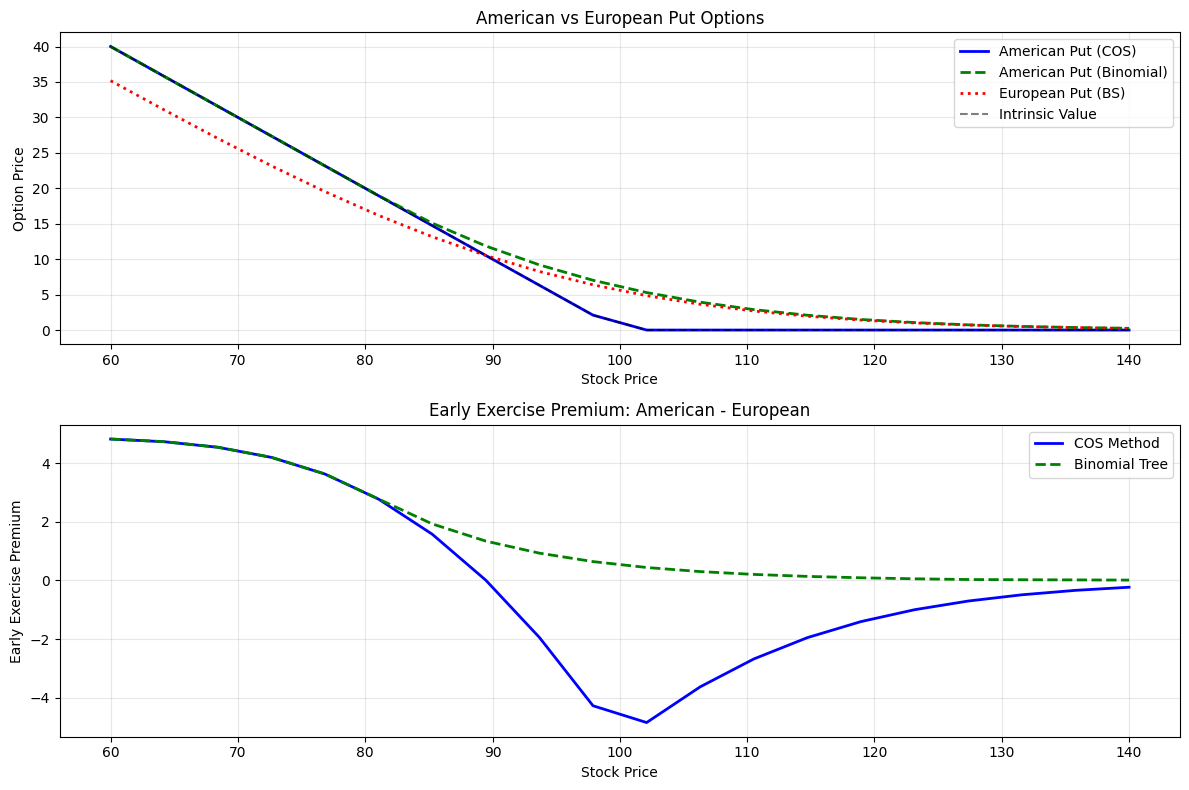

In [19]:
# Visualization
def plot_comparison():
    """Plot American vs European put values"""
    K, r, sigma, T = 100, 0.05, 0.2, 1.0
    S_range = np.linspace(60, 140, 20)
    
    american_prices = []
    european_prices = []
    binomial_prices = []
    
    print("Computing option values for plot...")
    for S in S_range:
        euro = european_put_bs(S, K, r, sigma, T)
        amer_cos = cos_american_put(S, K, r, sigma, T, N=64, M=30)
        amer_binom = binomial_american_put(S, K, r, sigma, T, N=100)
        
        european_prices.append(euro)
        american_prices.append(amer_cos)
        binomial_prices.append(amer_binom)
    
    plt.figure(figsize=(12, 8))
    
    # Option values comparison
    plt.subplot(2, 1, 1)
    plt.plot(S_range, american_prices, 'b-', linewidth=2, label='American Put (COS)')
    plt.plot(S_range, binomial_prices, 'g--', linewidth=2, label='American Put (Binomial)')
    plt.plot(S_range, european_prices, 'r:', linewidth=2, label='European Put (BS)')
    plt.plot(S_range, np.maximum(K - S_range, 0), 'k--', alpha=0.5, label='Intrinsic Value')
    plt.xlabel('Stock Price')
    plt.ylabel('Option Price')
    plt.title('American vs European Put Options')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Early exercise premium
    plt.subplot(2, 1, 2)
    premium_cos = np.array(american_prices) - np.array(european_prices)
    premium_binom = np.array(binomial_prices) - np.array(european_prices)
    plt.plot(S_range, premium_cos, 'b-', linewidth=2, label='COS Method')
    plt.plot(S_range, premium_binom, 'g--', linewidth=2, label='Binomial Tree')
    plt.xlabel('Stock Price')
    plt.ylabel('Early Exercise Premium')
    plt.title('Early Exercise Premium: American - European')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run visualization
plot_comparison()